<a href="https://colab.research.google.com/github/HIPPO1542/THDeepleaningg/blob/main/Bai1_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Bài 1

In [ ]:
import numpy as np
import tensorflow as tf
import keras
from keras.layers import Conv2D, Dense, MaxPool2D, Flatten
from keras.models import Sequential
from keras import Input
import matplotlib.pyplot as plt

# 1. Nạp bộ dữ liệu CIFAR10 có sẵn từ Keras
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

print(f"Kích thước tập Train ban đầu: X={X_train.shape}, y={y_train.shape}")
print(f"Kích thước tập Test ban đầu: X={X_test.shape}, y={y_test.shape}")

# 2. Định nghĩa danh sách các nhãn tương ứng (Từ 0 đến 9)
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# 3. Tiền xử lý dữ liệu ảnh màu (3 kênh màu RGB)
num_classes = 10
input_shape = (32, 32, 3) # Ảnh màu kích thước 32x32x3

# Chuẩn hóa pixel về đoạn [0, 1]
X_train = X_train.astype("float32") / 255
X_test = X_test.astype("float32") / 255

# Mã hóa nhãn sang dạng One-Hot Encoding
y_train_encoded = keras.utils.to_categorical(y_train, num_classes)
y_test_encoded = keras.utils.to_categorical(y_test, num_classes)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Kích thước tập Train ban đầu: X=(50000, 32, 32, 3), y=(50000, 1)
Kích thước tập Test ban đầu: X=(10000, 32, 32, 3), y=(10000, 1)


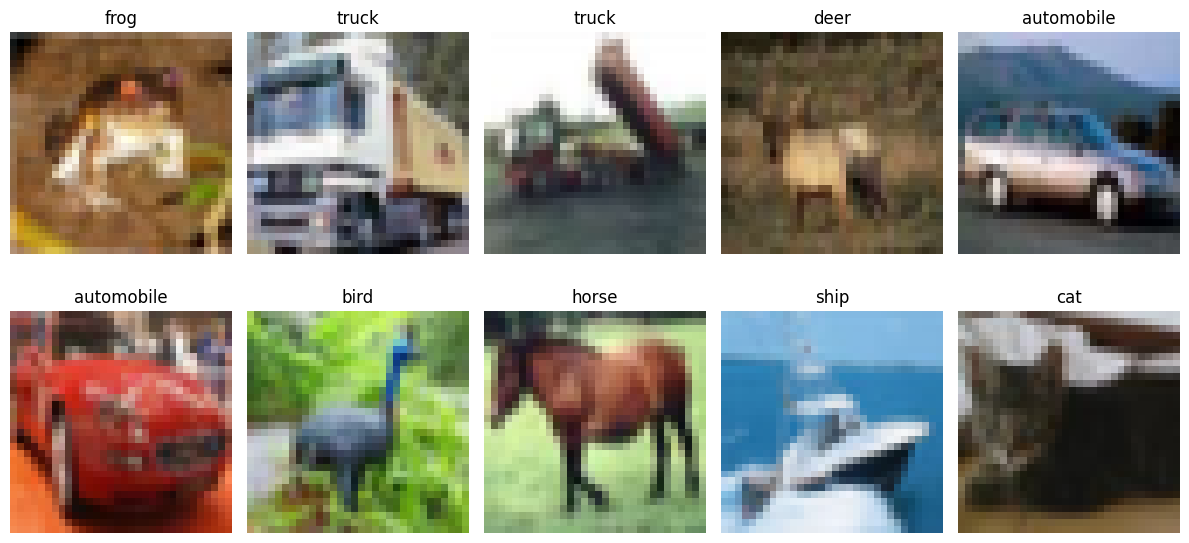

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(12, 6))
ax = axes.ravel()

for i in range(10):
    ax[i].imshow(X_train[i])
    # y_train[i][0] để lấy giá trị số nguyên của nhãn trong mảng 2D
    ax[i].title.set_text(class_names[y_train[i][0]])
    ax[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
model_cifar = Sequential()
model_cifar.add(Input(shape=input_shape))

# Khối mạng Chập thứ nhất
model_cifar.add(Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same'))
model_cifar.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
model_cifar.add(MaxPool2D(pool_size=(2, 2)))

# Khối mạng Chập thứ hai (Tăng số lượng bộ lọc khi ảnh nhỏ đi)
model_cifar.add(Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'))
model_cifar.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model_cifar.add(MaxPool2D(pool_size=(2, 2)))

# Khối Phân lớp (Fully Connected Layers)
model_cifar.add(Flatten())
model_cifar.add(Dense(units=128, activation='relu'))
model_cifar.add(Dense(units=num_classes, activation='softmax'))

model_cifar.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 30, 30, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 15, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 361,898 (1.38 MB)

 Trainable params: 361,898 (1.38 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Biên dịch
model_cifar.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Huấn luyện mô hình (Dùng 10 epochs để chạy thử nhanh trên Colab)
history_cifar = model_cifar.fit(X_train, y_train_encoded, batch_size=64, epochs=10, validation_split=0.1, verbose=1)

# Lưu trọng số mô hình bài 1
model_cifar.save_weights('cifar10.weights.h5')

# Đánh giá hiệu suất trên tập Test
score_cifar = model_cifar.evaluate(X_test, y_test_encoded, verbose=2)
print(f"\n[CIFAR10] Test accuracy: {score_cifar[1]:.4f} | Test loss: {score_cifar[0]:.4f}")

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 215s 298ms/step - accuracy: 0.4525 - loss: 1.5048 - val_accuracy: 0.5640 - val_loss: 1.2371
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 195s 277ms/step - accuracy: 0.6173 - loss: 1.0801 - val_accuracy: 0.6564 - val_loss: 0.9651
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 196s 279ms/step - accuracy: 0.6907 - loss: 0.8775 - val_accuracy: 0.6922 - val_loss: 0.8677
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 198s 282ms/step - accuracy: 0.7321 - loss: 0.7577 - val_accuracy: 0.7338 - val_loss: 0.7470
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 212s 296ms/step - accuracy: 0.7680 - loss: 0.6629 - val_accuracy: 0.7510 - val_loss: 0.7263
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 256s 287ms/step - accuracy: 0.7971 - loss: 0.5781 - val_accuracy: 0.7306 - val_loss: 0.7712
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 198s 281ms/step - accuracy: 0.8225 - loss: 0.5082 - val_accuracy: 0.7590 - val_loss: 0.7300
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 197s 280ms/step - accuracy: 0.8459 -

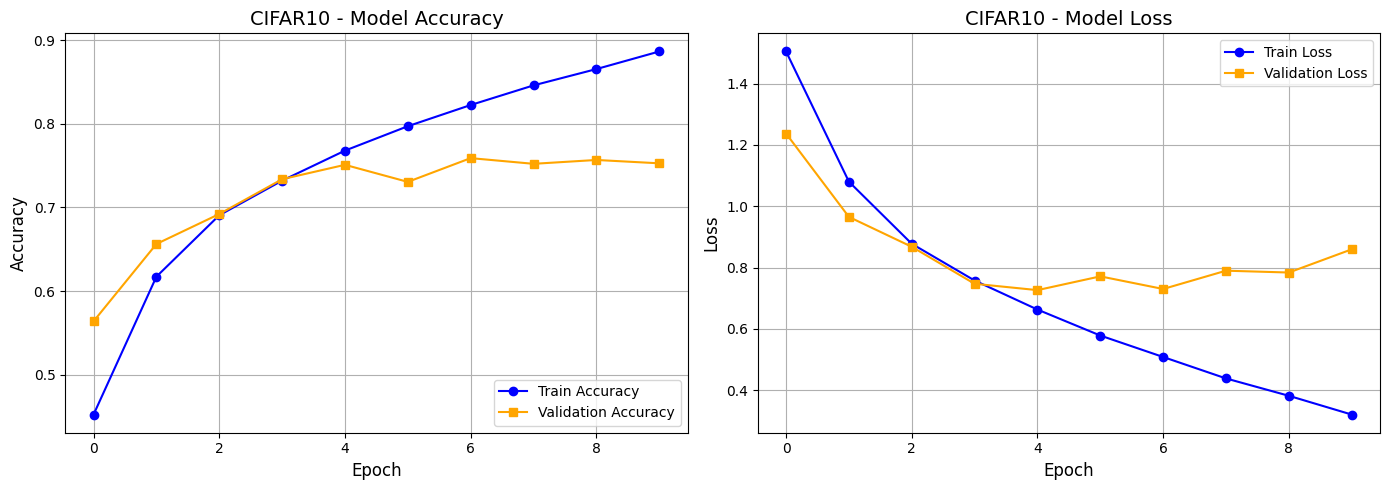

In [ ]:
import matplotlib.pyplot as plt

# Khởi tạo khung hình chứa 2 biểu đồ nằm cạnh nhau
plt.figure(figsize=(14, 5))

# 1. Biểu đồ độ chính xác (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(history_cifar.history['accuracy'], marker='o', color='blue', label='Train Accuracy')
plt.plot(history_cifar.history['val_accuracy'], marker='s', color='orange', label='Validation Accuracy')
plt.title('CIFAR10 - Model Accuracy', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.grid(True)
plt.legend(loc='lower right')

# 2. Biểu đồ độ lỗi (Loss)
plt.subplot(1, 2, 2)
plt.plot(history_cifar.history['loss'], marker='o', color='blue', label='Train Loss')
plt.plot(history_cifar.history['val_loss'], marker='s', color='orange', label='Validation Loss')
plt.title('CIFAR10 - Model Loss', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.grid(True)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

Saving chim15.jpg to chim15.jpg

Đang xử lý file dữ liệu: "chim15.jpg"
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step


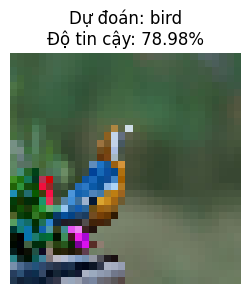

In [ ]:
from google.colab import files
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

# 1. Định nghĩa danh sách 10 nhãn chuẩn của bộ dữ liệu CIFAR10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# 2. Hiển thị hộp thoại chọn file để tải ảnh từ máy tính lên Colab
uploaded = files.upload()

for file_name in uploaded.keys():
    print(f'\nĐang xử lý file dữ liệu: "{file_name}"')

    # 3. Đọc ảnh và ép kích thước về dạng ảnh màu 32x32 phù hợp với cấu trúc đầu vào bài 1
    img = load_img(file_name, target_size=(32, 32), color_mode='rgb')

    # Chuyển đổi dữ liệu ảnh thành mảng numpy
    img_array = img_to_array(img)

    # Chuẩn hóa giá trị pixel ảnh về đoạn [0, 1] giống như khi huấn luyện mạng
    img_array = img_array.astype('float32') / 255.0

    # Định hình lại mảng (reshape) thêm chiều batch thành (1, 32, 32, 3)
    img_batch = np.expand_dims(img_array, axis=0)

    # 4. Đưa ảnh vào mô hình CIFAR10 đã huấn luyện để dự đoán
    prediction = model_cifar.predict(img_batch)
    predicted_class_idx = np.argmax(prediction)
    confidence = np.max(prediction) * 100

    # 5. Trực quan hóa hình ảnh kèm kết quả phân lớp của mạng CNN
    plt.figure(figsize=(3, 3))
    plt.imshow(img_array)  # Hiển thị ảnh màu gốc sau khi resize
    plt.title(f"Dự đoán: {class_names[predicted_class_idx]}\nĐộ tin cậy: {confidence:.2f}%")
    plt.axis('off')
    plt.show()

bài 3


In [ ]:
# Nạp dữ liệu Fashion-MNIST
(X_train_fashion, y_train_fashion), (X_test_fashion, y_test_fashion) = keras.datasets.fashion_mnist.load_data()

print(f"Kích thước tập Fashion Train: X={X_train_fashion.shape}, y={y_train_fashion.shape}")

# Danh sách các nhãn thời trang
fashion_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Skirt', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Tiền xử lý (Định hình ảnh về cấu trúc 28x28x1 kênh màu trắng đen)
X_train_fashion = X_train_fashion.astype("float32") / 255
X_test_fashion = X_test_fashion.astype("float32") / 255

X_train_fashion = X_train_fashion.reshape(X_train_fashion.shape[0], 28, 28, 1)
X_test_fashion = X_test_fashion.reshape(X_test_fashion.shape[0], 28, 28, 1)

# Mã hóa One-Hot
y_train_fashion_encoded = keras.utils.to_categorical(y_train_fashion, 10)
y_test_fashion_encoded = keras.utils.to_categorical(y_test_fashion, 10)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Kích thước tập Fashion Train: X=(60000, 28, 28), y=(60000,)


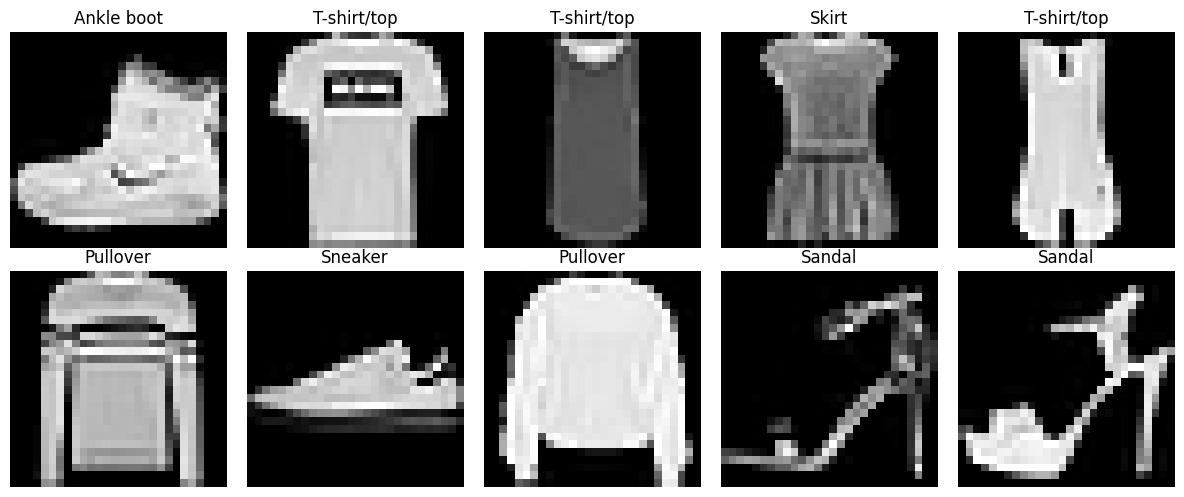

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(12, 5))
ax = axes.ravel()

for i in range(10):
    ax[i].imshow(X_train_fashion[i].reshape(28, 28), cmap='gray')
    ax[i].title.set_text(fashion_names[y_train_fashion[i]])
    ax[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
model_fashion = Sequential()
model_fashion.add(Input(shape=(28, 28, 1)))

# Tầng chập và lấy mẫu lớn nhất tương tự bài mẫu trong file
model_fashion.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
model_fashion.add(MaxPool2D(pool_size=(2, 2)))
model_fashion.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model_fashion.add(MaxPool2D(pool_size=(2, 2)))

model_fashion.add(Flatten())
model_fashion.add(Dense(units=128, activation='relu'))
model_fashion.add(Dense(units=10, activation='softmax'))

# Biên dịch và chạy huấn luyện
model_fashion.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history_fashion = model_fashion.fit(X_train_fashion, y_train_fashion_encoded, batch_size=128, epochs=10, validation_split=0.1, verbose=1)

# Lưu trọng số mô hình bài 3
model_fashion.save_weights('fashion_mnist.weights.h5')

# Đánh giá hiệu suất
score_fashion = model_fashion.evaluate(X_test_fashion, y_test_fashion_encoded, verbose=2)
print(f"\n[Fashion-MNIST] Test accuracy: {score_fashion[1]:.4f} | Test loss: {score_fashion[0]:.4f}")

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 51s 115ms/step - accuracy: 0.8009 - loss: 0.5550 - val_accuracy: 0.8600 - val_loss: 0.3838
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 79s 108ms/step - accuracy: 0.8743 - loss: 0.3550 - val_accuracy: 0.8802 - val_loss: 0.3354
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 84s 112ms/step - accuracy: 0.8886 - loss: 0.3069 - val_accuracy: 0.8872 - val_loss: 0.3145
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 46s 109ms/step - accuracy: 0.8987 - loss: 0.2795 - val_accuracy: 0.8885 - val_loss: 0.3091
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 83s 111ms/step - accuracy: 0.9053 - loss: 0.2576 - val_accuracy: 0.9062 - val_loss: 0.2665
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 46s 110ms/step - accuracy: 0.9127 - loss: 0.2370 - val_accuracy: 0.9042 - val_loss: 0.2608
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 45s 107ms/step - accuracy: 0.9188 - loss: 0.2200 - val_accuracy: 0.9043 - val_loss: 0.2590
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 46s 110ms/step - accuracy: 0.9255 - loss: 0

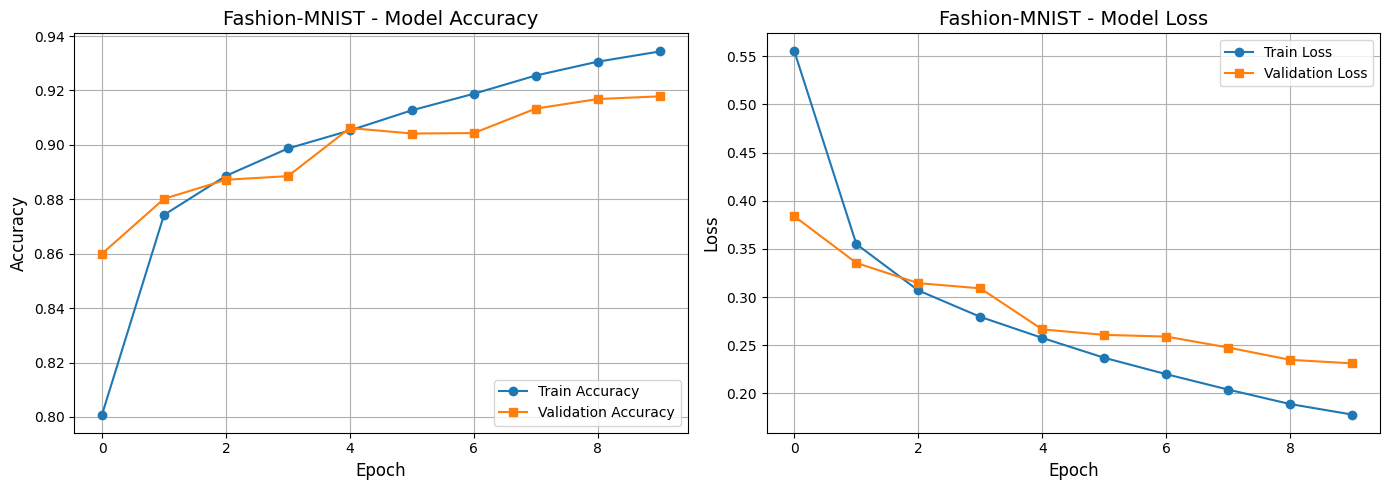

In [ ]:
import matplotlib.pyplot as plt

# Tạo khung hình chứa 2 biểu đồ nằm cạnh nhau
plt.figure(figsize=(14, 5))

# 1. Biểu đồ độ chính xác (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(history_fashion.history['accuracy'], marker='o', label='Train Accuracy')
plt.plot(history_fashion.history['val_accuracy'], marker='s', label='Validation Accuracy')
plt.title('Fashion-MNIST - Model Accuracy', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.grid(True)
plt.legend(loc='lower right')

# 2. Biểu đồ độ lỗi (Loss)
plt.subplot(1, 2, 2)
plt.plot(history_fashion.history['loss'], marker='o', label='Train Loss')
plt.plot(history_fashion.history['val_loss'], marker='s', label='Validation Loss')
plt.title('Fashion-MNIST - Model Loss', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.grid(True)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

Saving download.jpg to download.jpg

Đang xử lý file: "download.jpg"
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


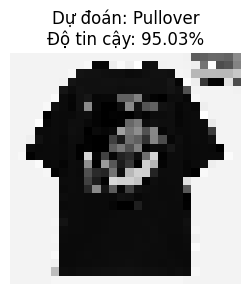

In [ ]:
from google.colab import files
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

# 1. Định nghĩa lại danh sách nhãn của bài 3
fashion_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Skirt', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# 2. Yêu cầu người dùng tải ảnh lên từ máy tính
uploaded = files.upload()

for file_name in uploaded.keys():
    print(f'\nĐang xử lý file: "{file_name}"')

    # 3. Đọc ảnh và tiền xử lý về dạng ảnh xám kích thước 28x28 tương thích với mô hình
    img = load_img(file_name, target_size=(28, 28), color_mode='grayscale')

    # Chuyển ảnh thành mảng numpy
    img_array = img_to_array(img)

    # Chuẩn hóa giá trị pixel về đoạn [0, 1] giống lúc huấn luyện
    img_array = img_array.astype('float32') / 255.0

    # Định hình lại (reshape) thành dạng batch (1, 28, 28, 1) để đưa vào mạng CNN
    img_batch = np.expand_dims(img_array, axis=0)

    # 4. Sử dụng mô hình đã huấn luyện ở bài 3 để dự đoán
    prediction = model_fashion.predict(img_batch)
    predicted_class_idx = np.argmax(prediction)
    confidence = np.max(prediction) * 100

    # 5. Hiển thị kết quả dự đoán trực quan
    plt.figure(figsize=(3, 3))
    plt.imshow(img_array.reshape(28, 28), cmap='gray')
    plt.title(f"Dự đoán: {fashion_names[predicted_class_idx]}\nĐộ tin cậy: {confidence:.2f}%")
    plt.axis('off')
    plt.show()